## Week 4 Day 3 - create_agent, the agent layer

In [1]:
# Importing required libraries
from dotenv import load_dotenv
from IPython.display import Image, display, Markdown
from pydantic import BaseModel, Field
from langchain_openai import AzureChatOpenAI
from langchain.agents import create_agent
from langchain.agents.middleware import wrap_tool_call
from langchain_core.tools import tool
from langgraph.checkpoint.memory import MemorySaver
from langchain_mcp_adapters.client import MultiServerMCPClient
from langgraph.graph.state import CompiledStateGraph
import os
import sys
import json
load_dotenv(override = True)

True

In [2]:
# Let's see if the API key is working/helping us to call LLM from Azure Foundry
import os
# From OpenAI
AZURE_OPENAI_API_KEY= os.getenv("AZURE_OPENAI_API_KEY")
AZURE_OPENAI_MODEL_DEPLOYMENT = os.getenv("AZURE_OPENAI_DEPLOYMENT")
AZURE_OPENAI_ENDPOINT = os.getenv("AZURE_OPENAI_ENDPOINT")
AZURE_OPENAI_API_VERSION = os.getenv("AZURE_OPENAI_API_VERSION")
AZURE_OPENAI_DEPLOYMENT_GPT_41 = os.getenv("AZURE_OPENAI_DEPLOYMENT_GPT_41")
AZURE_OPENAI_DEPLOYMENT_GPT_54_mini = os.getenv("AZURE_OPENAI_DEPLOYMENT_GPT_54_mini")
AZURE_OPENAI_DEPLOYMENT_GPT_55 = os.getenv("AZURE_OPENAI_DEPLOYMENT_GPT_55")
AZURE_OPENAI_DEPLOYMENT_GPT_4O_mini = os.getenv("AZURE_OPENAI_DEPLOYMENT_GPT_4O_mini")
if AZURE_OPENAI_API_KEY:
    print("AZURE_OPENAI_API_KEY is available")
else:
    print("AZURE_OPENAI_API_KEY is not available")

# From Anthropic
AZURE_CLAUDE_DEPLOYMENT_OPUS_48=os.getenv("AZURE_CLAUDE_DEPLOYMENT_OPUS_48")
AZURE_CLAUDE_ENDPOINT=os.getenv("AZURE_CLAUDE_ENDPOINT")
AZURE_CLAUDE_API_KEY=os.getenv("AZURE_CLAUDE_API_KEY")
if AZURE_CLAUDE_API_KEY:
    print("AZURE_CLAUDE_API_KEY is avaiable")
else:
    print("AZURE_CLAUDE_API_KEY is not available")

# setting up tavily api key
TAVILY_API_KEY=os.getenv("TAVILY_API_KEY")
SERP_API_KEY=os.getenv("SERP_API_KEY")
if SERP_API_KEY:
    print("SERP Available")
else:
    print("SERP Not Available")

EMAIL_ADDRESS = os.getenv("EMAIL_ADDRESS_TO")
if EMAIL_ADDRESS:
    print("Email address present!")
else:
    print("Email adderess not found!")

AZURE_OPENAI_API_KEY is available
AZURE_CLAUDE_API_KEY is avaiable
SERP Available
Email address present!


In [ ]:
## Setting up the llm from Azure Foundry
llm = AzureChatOpenAI(
    api_key = AZURE_OPENAI_API_KEY,
    azure_endpoint = AZURE_OPENAI_ENDPOINT,
    azure_deployment = AZURE_OPENAI_DEPLOYMENT_GPT_54_mini,
    api_version = AZURE_OPENAI_API_VERSION
)

: 

### Part 01: The simplest agent

In [4]:
# let's create a first sample agent using langchain
agent = create_agent(
    model = llm,
    system_prompt = "You're a helpfull assistant who answers concisely.",
)
message = {
    "messages": [
        {
            "role":"user",
            "content": "What is the Model Context Protocol, in two sentences?"
        }
    ]
}
result = agent.invoke(message)
print(result['messages'][-1].content)

The Model Context Protocol (MCP) is an open standard for connecting AI models to external tools, data sources, and services in a consistent way. It lets applications expose context and capabilities to models through a common interface, making integrations easier and more reusable.


#### And it's async twin: ainvoke

In [12]:
message = {
    "messages":[
        {
            "role": "user",
            "content": "give me a phrase to describe a person who think/visualize making a empire with his own grit."
        }
    ]
}
result = await agent.ainvoke(message)
print(result['messages'][-1].content)

You could say:

**“A self-made empire-builder.”**

Other good options:
- **“A visionary with an empire-making mindset”**
- **“A gritty self-made builder”**
- **“An empire-minded dreamer”**
- **“A relentless self-made visionary”**

If you want, I can make it sound more **powerful, poetic, or modern**.


In [ ]:
## print using Mardown format
display(Markdown(result['messages'][-1].content))

You could say:

**“A self-made empire-builder.”**

Other good options:
- **“A visionary with an empire-making mindset”**
- **“A gritty self-made builder”**
- **“An empire-minded dreamer”**
- **“A relentless self-made visionary”**

If you want, I can make it sound more **powerful, poetic, or modern**.

### Part 02: tools

In [5]:
@tool
def get_weather(city: str) -> str:
    """ Return today's weather for a city. """
    print("******** Weather Tool Called ***********")
    pretend = {
        "London":"rainy, 14 degrees", 
        "Rome": "sunny, 27 degrees"
    }
    return pretend.get(city, "clear, 20 degrees")

@tool
def get_population(city: str) -> str:
    """Return the population of a city. """
    print("********* Population Tool Called ***********")
    pretend = {
        "London": "8.9 Million", 
        "Rome": "2.8 million"
    }
    return pretend.get(city, "not f**ks given mode")

tools = [get_weather, get_population]
tools

[StructuredTool(name='get_weather', description="Return today's weather for a city.", args_schema=<class 'langchain_core.utils.pydantic.get_weather'>, func=<function get_weather at 0x0000027F26B44EE0>),
 StructuredTool(name='get_population', description='Return the population of a city.', args_schema=<class 'langchain_core.utils.pydantic.get_population'>, func=<function get_population at 0x0000027F22BB4B80>)]

In [5]:
# making a function to make ready a user prompt with acutal prompt
def user_prompt(prompt: str) -> dict:
    message = {
        "messages":[
            {
                "role": "user",
                "content": prompt
            }
        ]
    }
    return message
user_prompt("What is my name")

# make a function to print the results of agent call in Markdown format
def print_markdown(result: dict) -> str:
    print("Agent's/LLM's answer is: \n")
    return display(Markdown(result['messages'][-1].content))

## Let's make a function of visualizing agent's structure
def draw_structure(agent: CompiledStateGraph) -> bytes:
    return display(Image(agent.get_graph().draw_png()))



In [25]:
# let's call llm with some tools
agent = create_agent(
    model = llm,
    system_prompt = "You are a travel assistant. Use your tools to answer questions about different cities.",
    tools = tools
)
result = agent.invoke(user_prompt("What is the weather and population of Rome..?"))
print_markdown(result)

******** Weather Tool Called ***********
********* Population Tool Called ***********


Rome is **sunny, 27 degrees**, and its population is **2.8 million**.

### Let's reveal: it's a Langgraph graph

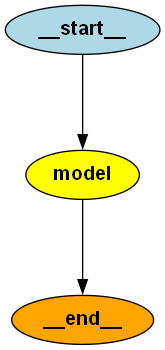

In [7]:
draw_structure(agent)

### Part 03: Memory

Nice — Rome is a great choice.

If you want, I can help you plan things like:
- best time to go
- top sights and neighborhoods
- food recommendations
- itinerary ideas
- weather and population info

If you’d like, I can also check **today’s weather in Rome** for you.

******** Weather Tool Called ***********


In Rome today, it’s **sunny and 27°C**.


Agent Structure: 


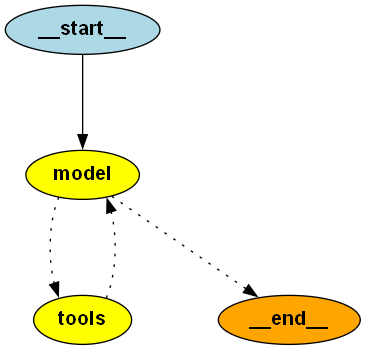

In [35]:
# let's define a agent
memory_agent = create_agent(
    model = llm,
    system_prompt = "You are a user helper tool.",
    checkpointer = MemorySaver(),
    tools = tools
)

# define a config for agent
config = {
    "configurable": {
        "thread_id": "trip_planning"
    }
}
result = memory_agent.invoke(user_prompt("I am planning a trip to Rome."), config = config)
print_markdown(result)
result = memory_agent.invoke(user_prompt("What is weather like where I am planning to go..?"), config = config)
print_markdown(result)
print("\nAgent Structure: ")
draw_structure(memory_agent)

### Part 04: Structured output

In [36]:
# let's define a pydantic class to get a structure output
class CityReport(BaseModel):
    city: str = Field(
        description = "The city name"
    )
    weather: str = Field(
        description = "A short weather description"
    )
    population: str = Field(
        description = "The population of city"
    )
# let's give this format above defined to a agent
report_agent = create_agent(
    model = llm,
    system_prompt = "You're a helper chat agent which give answer in language of Haryana (state in India) which is Haryanvi",
    tools=tools,
    response_format = CityReport
)
result = report_agent.invoke(user_prompt("Give me a report on London.."))
print_markdown(result)
print(result['structured_response'])
print(result['structured_response'].weather)

******** Weather Tool Called ***********
********* Population Tool Called ***********


{"city":"London","weather":"rainy, 14 degrees","population":"8.9 Million"}

city='London' weather='rainy, 14 degrees' population='8.9 Million'
rainy, 14 degrees


### Part 05: Middleware

In [38]:
@wrap_tool_call
def log_tool_calls(request, handler):
    call = request.tool_call
    print(f"  [middleware] calling {call['name']} with {call['args']}")
    return handler(request)

watched_agent = create_agent(
    model = llm,
    tools=tools,
    system_prompt=  "You're a travel assistant, user your tools to answer the queries.",
    middleware = [log_tool_calls]
)

result = watched_agent.invoke(user_prompt("Weather and population of Rome..?"))
print_markdown(result)

  [middleware] calling get_weather with {'city': 'Rome'}
******** Weather Tool Called ***********
  [middleware] calling get_population with {'city': 'Rome'}
********* Population Tool Called ***********
Agent's/LLM's answer is: 



Rome: sunny, 27 degrees, population about 2.8 million.

### Part 06: Node and Playwright

In [ ]:
## Will be running a tools published by someone in Javascript using npx on your PC
os.environ["NODE_TLS_REJECT_UNAUTHORIZED"] = "0" # for bypassing the SSL certficate error by setting npm to not check for any certificate (not safe for prod use)
!npx -y playwright@latest screenshot --channel=chrome https://news.ycombinator.com playwright_check.png

(node:18852) Warning: Setting the NODE_TLS_REJECT_UNAUTHORIZED environment variable to '0' makes TLS connections and HTTPS requests insecure by disabling certificate verification.
(Use `node --trace-warnings ...` to show where the warning was created)


Navigating to https://news.ycombinator.com
Capturing screenshot into playwright_check.png


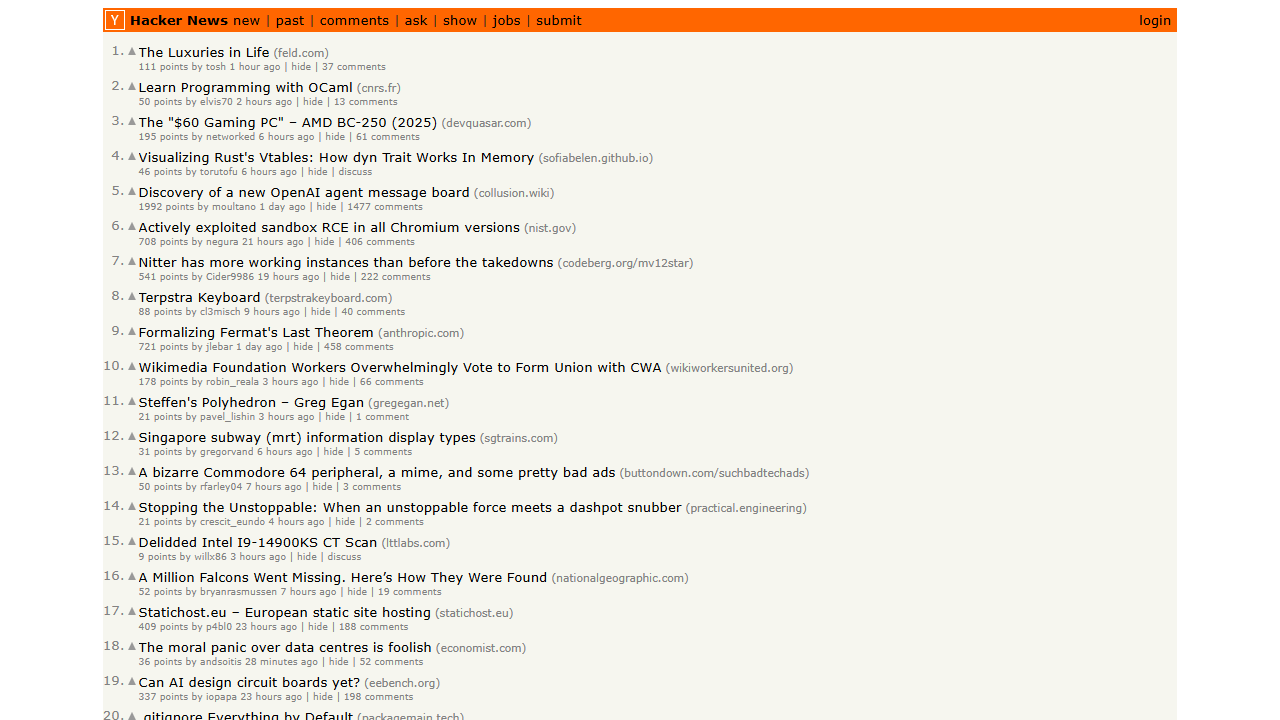

In [5]:
display(Image("playwright_check.png"))

### Part 06: an MCP server, and a real browser

In [6]:
## A small coding patch to run for Windows as to handle programs error log location
import sys
if sys.platform == "win32":
    import subprocess
    from functools import partial
    import langchain_mcp_adapters.sessions as mcp_sessions

    mcp_sessions.stdio_client = partial(mcp_sessions.stdio_client, errlog=subprocess.DEVNULL)
    print("Applied the windows adjustment")
else:
    print("Not Windows, so nothing to do here!")


Applied the windows adjustment


In [9]:
# let's set up the MCP client 
client = MultiServerMCPClient(
    {
        "playwright":{
            "transport": "stdio",
            "command": "npx",
            "args": ["-y", "@playwright/mcp@latest", "--isolated"]
        }
    }
)
browser_tools = await client.get_tools()
print(f"loaded {len(browser_tools)} browser tools, for example: ")
for t in browser_tools:
    print(" -", t.name)

loaded 24 browser tools, for example: 
 - browser_close
 - browser_resize
 - browser_console_messages
 - browser_handle_dialog
 - browser_evaluate
 - browser_file_upload
 - browser_drop
 - browser_find
 - browser_fill_form
 - browser_press_key
 - browser_type
 - browser_navigate
 - browser_navigate_back
 - browser_network_requests
 - browser_network_request
 - browser_run_code_unsafe
 - browser_take_screenshot
 - browser_snapshot
 - browser_click
 - browser_drag
 - browser_hover
 - browser_select_option
 - browser_tabs
 - browser_wait_for


In [10]:
## Setting up the llm from Azure Foundry for MCP call 
llm_mcp = AzureChatOpenAI(
    api_key = AZURE_OPENAI_API_KEY,
    azure_endpoint = AZURE_OPENAI_ENDPOINT,
    azure_deployment = AZURE_OPENAI_DEPLOYMENT_GPT_41,
    api_version = AZURE_OPENAI_API_VERSION
)

In [ ]:
## now let's create a agent and ask it to do things using mcp server of playwright
browser_agent = create_agent(
    model = llm_mcp,
    tools = browser_tools,
    system_prompt = "You're a web research assistant. Use the browser tools to complete the task, then report clearly."
)

result = await browser_agent.ainvoke(user_prompt("Go to https://news.ycombinator.com and tell me the titles of the top five stories on the front page."))
print_markdown(result)